# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Datasets

In [3]:
customers = pd.read_csv('../data/processed/customers_cleaned.csv')
order_items = pd.read_csv('../data/processed/order_items_cleaned.csv')
order_reviews = pd.read_csv('../data/processed/order_reviews_cleaned.csv')
orders = pd.read_csv('../data/processed/orders_cleaned.csv')
products = pd.read_csv('../data/processed/products_cleaned.csv')
product_category = pd.read_csv('../data/processed/product_category_cleaned.csv')

# Satisfaction Analysis

In [4]:
# Dataframe de satisfacao
df_satisfaction = orders.merge(order_reviews, on='order_id', how='left')
df_satisfaction = df_satisfaction.merge(order_items, on='order_id', how='left')
df_satisfaction = df_satisfaction.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
df_satisfaction = df_satisfaction.merge(product_category, on='product_category_name', how='left')
df_satisfaction = df_satisfaction.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

In [5]:
# Convertendo colunas de data para datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_columns:
    if col in df_satisfaction.columns:
        df_satisfaction[col] = pd.to_datetime(df_satisfaction[col])

## 1. Overall Score Distribution

In [6]:
# 1. Qual a distribuicao geral das notas?
distribuicao_notas = df_satisfaction['review_score'].value_counts().to_frame()
distribuicao_notas

,count
review_score,
5.0,63596
4.0,21348
1.0,14775
3.0,9476
2.0,3936


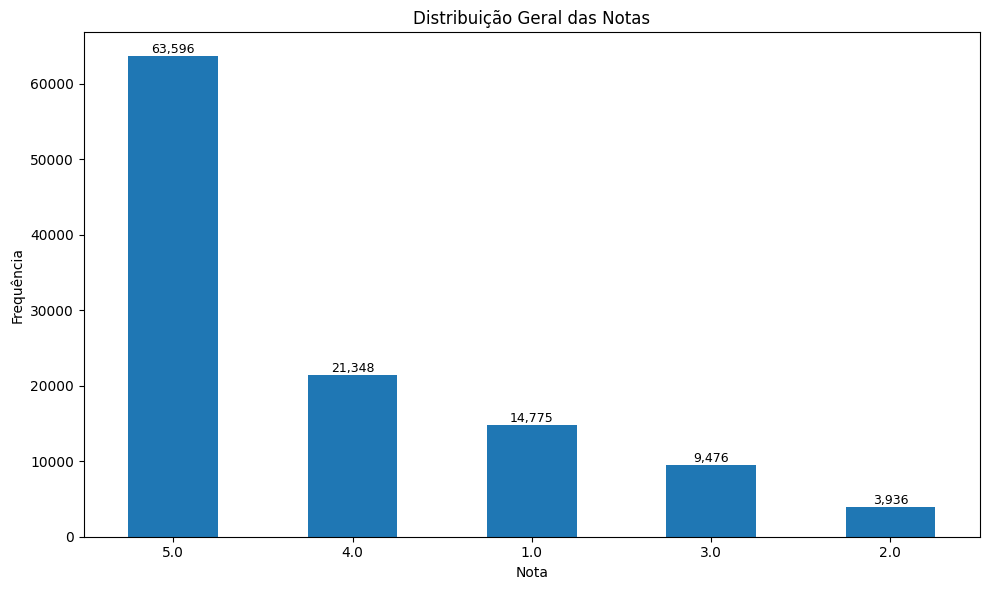

In [7]:
ax = distribuicao_notas.plot(kind='bar', figsize=(10, 6))
plt.title('Distribuição Geral das Notas')
plt.xlabel('Nota')
plt.ylabel('Frequência')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                    
        f'{int(bar.get_height()):,}',      
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()

## 2. Average Score by Category

In [8]:
# 2. Qual a nota media por categoria de produto?
nota_media_categoria = df_satisfaction.groupby('product_category_name_english')['review_score'].mean().to_frame().round(2).sort_values(by='review_score', ascending=False)
nota_media_categoria

,review_score
product_category_name_english,
cds_dvds_musicals,4.64
fashion_childrens_clothes,4.50
books_general_interest,4.45
costruction_tools_tools,4.44
flowers,4.42
...,...
fashion_male_clothing,3.64
home_comfort_2,3.63
office_furniture,3.49


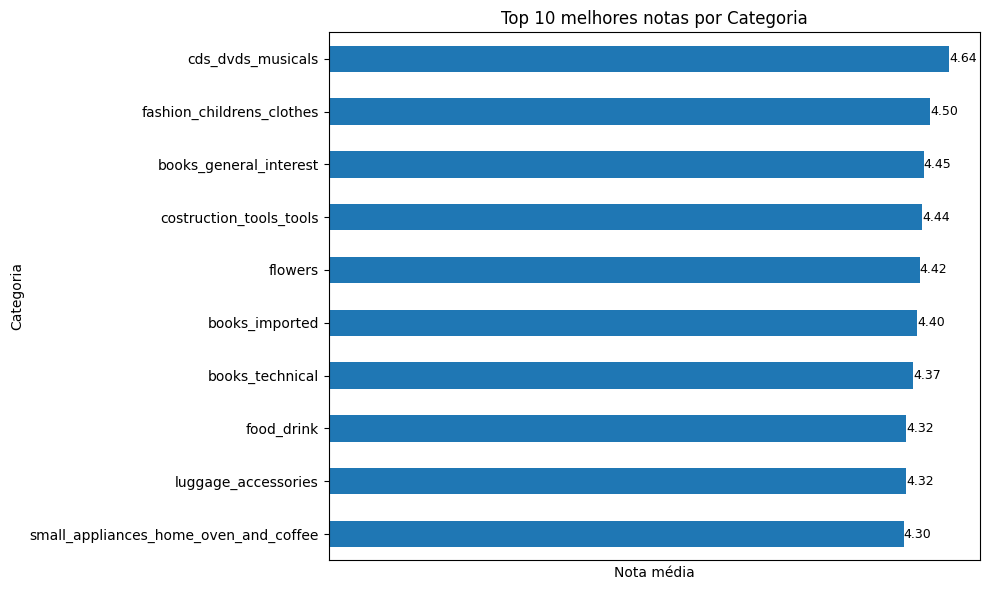

In [9]:
ax = nota_media_categoria.head(10).sort_values(by= 'review_score', ascending=True).plot(kind= 'barh', figsize=(10, 6))
plt.title('Top 10 melhores notas por Categoria')
plt.xlabel('Nota média')
plt.ylabel('Categoria')

for bar in ax.patches:
    ax.text(
        bar.get_width(),                    
        bar.get_y() + bar.get_height() / 2, 
        f'{(bar.get_width()):,.2f}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.legend().remove()
plt.xticks([])
plt.tight_layout()
plt.show()

## 3. Late Orders vs Score

In [10]:
# 3. Pedidos atrasados tem nota menor?]
df_satisfaction['situacao'] = np.where(
    df_satisfaction['order_delivered_customer_date'] > df_satisfaction['order_estimated_delivery_date'],
    'Atrasado',
    'No Prazo'
)

In [11]:
df_satisfaction.groupby('situacao')['review_score'].mean().to_frame().round(2).sort_values(by='review_score', ascending=False)

,review_score
situacao,
No Prazo,4.14
Atrasado,2.55


> **Insight:** pedidos atrasados tem nota media 38% menor que pedidos entregues
> no prazo (2.55 vs 4.14), confirmando que o prazo de entrega e o principal
> driver de insatisfacao do cliente.

## 4. Vendor Response Time

In [12]:
# 4. Qual o tempo medio de resposta do vendedor ao review?
df_satisfaction['tempo_resposta_review'] = (
    df_satisfaction['review_answer_timestamp'] - df_satisfaction['review_creation_date']
)

In [13]:
df_satisfaction['tempo_resposta_review'].dt.days.mean()
print(f"Tempo medio de resposta ao review: {df_satisfaction['tempo_resposta_review'].dt.days.mean():.1f} dias")

Tempo medio de resposta ao review: 2.6 dias


In [14]:
conditions = [
    df_satisfaction['tempo_resposta_review'].dt.days == 0,
    df_satisfaction['tempo_resposta_review'].dt.days <= 3,
    df_satisfaction['tempo_resposta_review'].dt.days <= 7,
    df_satisfaction['tempo_resposta_review'].dt.days > 7
]

choices = [
    'Mesmo dia',
    '1-3 dias',
    '4-7 dias',
    'Acima de 7 dias'
]

df_satisfaction['faixa_resposta'] = np.select(conditions, choices, default='Sem resposta')

In [15]:
df_satisfaction.groupby('faixa_resposta')['review_score'].mean().to_frame().round(2).sort_values(by='review_score', ascending=False)

,review_score
faixa_resposta,
1-3 dias,4.11
4-7 dias,3.98
Acima de 7 dias,3.95
Mesmo dia,3.82
Sem resposta,NaN


> **Insight:** respostas no mesmo dia estao associadas as menores notas (3.82),
> sugerindo causalidade invertida, vendedores respondem mais rapido quando
> recebem reclamacoes, nao o contrario.

## 5. Categories with Most Complaints

In [16]:
# 5. Quais categorias tem mais reclamacoes (notas 1 e 2)?
qtd_reclamcoes_categoria =(df_satisfaction[df_satisfaction['review_score'].between(1, 2)]
    .groupby('product_category_name_english')['review_score'].count().to_frame()
    .sort_values(by='review_score', ascending=False)
    .head(10))
qtd_reclamcoes_categoria

,review_score
product_category_name_english,
bed_bath_table,2112
furniture_decor,1621
computers_accessories,1461
health_beauty,1321
sports_leisure,1260
housewares,1086
watches_gifts,967
telephony,761
garden_tools,696


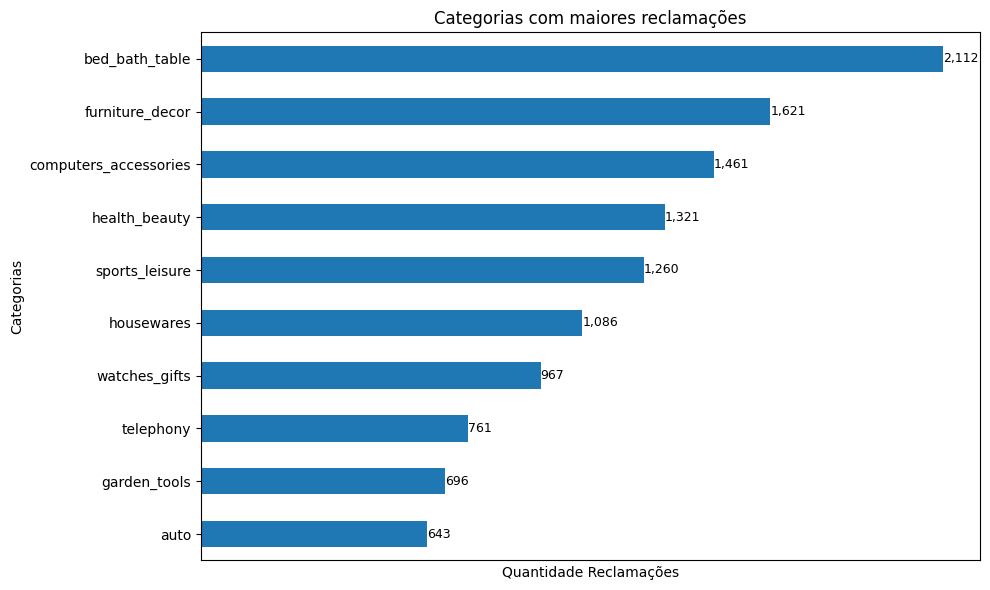

In [17]:
ax = qtd_reclamcoes_categoria.sort_values(by='review_score', ascending=True).plot(kind='barh', figsize=(10, 6))
plt.title('Categorias com maiores reclamações')
plt.xlabel('Quantidade Reclamações')
plt.ylabel('Categorias')

for bar in ax.patches:
    ax.text(
        bar.get_width(),                    
        bar.get_y() + bar.get_height() / 2, 
        f'{int(bar.get_width()):,}',
        va='center',
        ha='left',
        fontsize=9
    )

plt.legend().remove()
plt.xticks(rotation=45, ha='right')
plt.xticks([])
plt.tight_layout()
plt.show()

## 6. Delivery Time vs Score

In [18]:
# 6. Existe relacao entre tempo de entrega e nota?
df_satisfaction['tempo_entrega'] = (
    df_satisfaction['order_delivered_customer_date'] - df_satisfaction['order_purchase_timestamp']
)

In [19]:
df_satisfaction['tempo_entrega_dias'] = df_satisfaction['tempo_entrega'].dt.days

In [20]:
df_satisfaction[['tempo_entrega_dias', 'review_score']].corr().round(2)

,tempo_entrega_dias,review_score
tempo_entrega_dias,1.0,-0.3
review_score,-0.3,1.0


> **Insight:** existe correlacao negativa moderada (-0.30) entre tempo de entrega
> e nota do cliente. Entregas mais rapidas estao associadas a notas mais altas,
> sendo o tempo de entrega um driver relevante de satisfacao.

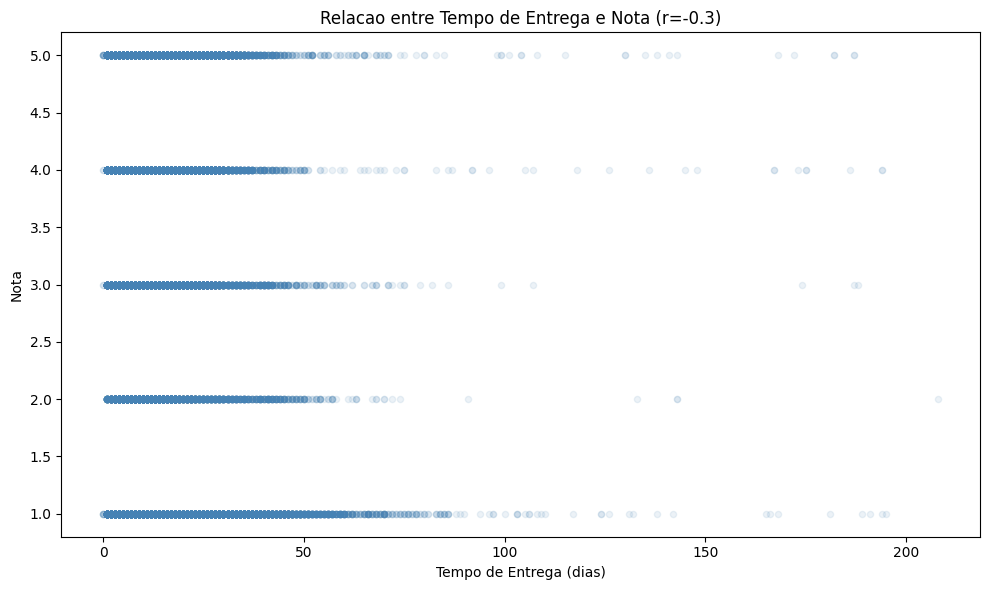

In [21]:
corr_value = df_satisfaction[['tempo_entrega_dias', 'review_score']].corr().round(2).iloc[0, 1]

ax = df_satisfaction.plot(
    kind='scatter',
    x='tempo_entrega_dias',
    y='review_score',
    figsize=(10, 6),
    alpha=0.1,
    color='steelblue'
)

plt.title(f'Relacao entre Tempo de Entrega e Nota (r={corr_value})')
plt.xlabel('Tempo de Entrega (dias)')
plt.ylabel('Nota')
plt.tight_layout()
plt.show()

## 7. Satisfied Customers Percentage

In [22]:
# 7. Qual o percentual de clientes satisfeitos (notas 4 e 5)?
total_avaliacoes = df_satisfaction['review_score'].count()
clientes_satisfeitos = df_satisfaction[df_satisfaction['review_score'].between(4, 5)]['review_score'].count()

percentual = (clientes_satisfeitos / total_avaliacoes) * 100
print(f"Clientes satisfeitos: {percentual:.2f}%")

Clientes satisfeitos: 75.08%


## 8. Worst States by Score

In [31]:
# 8. Quais estados tem as piores avaliacoes?
estados_piores_reviews = df_satisfaction.groupby('customer_state')['review_score'].mean().to_frame().sort_values(by='review_score', ascending=True).head(10)
estados_piores_reviews

,review_score
customer_state,
RR,3.576923
MA,3.697590
AL,3.713647
PA,3.784515
CE,3.792032
RJ,3.793639
BA,3.801954
SE,3.809278
PI,3.894444


> **Insight:** estados do Norte e Nordeste concentram as piores avaliacoes,
> provavelmente pela maior distancia dos centros de distribuicao e consequente
> maior tempo de entrega. RJ e uma excecao que merece investigacao adicional.

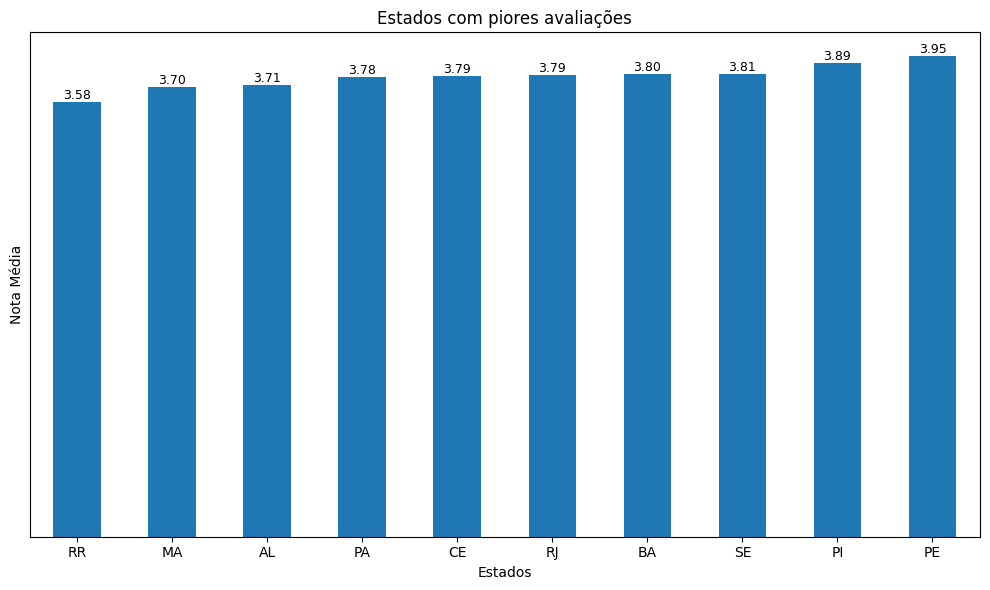

In [41]:
ax = estados_piores_reviews.plot(kind='bar', figsize=(10, 6))
plt.title('Estados com piores avaliações')
plt.xlabel('Estados')
plt.ylabel('Nota Média')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                    
        f'{(bar.get_height()):,.2f}',      
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.legend().remove()
plt.yticks([])
plt.tight_layout()
plt.show()

## 9. Score Over Time

In [60]:
# 9. A nota media melhorou ao longo do tempo?
mask = (df_satisfaction['review_creation_date'].dt.year >= 2017) & (df_satisfaction['review_creation_date'].dt.year <= 2018)

notas_tempo = (df_satisfaction[mask].groupby(df_satisfaction[mask]['review_creation_date'].dt.to_period('M'))['review_score'].mean().to_frame().round(2))
notas_tempo

,review_score
review_creation_date,
2017-01,4.19
2017-02,4.27
2017-03,4.01
2017-04,3.97
2017-05,4.07
2017-06,4.09
2017-07,4.12
2017-08,4.19
2017-09,4.14


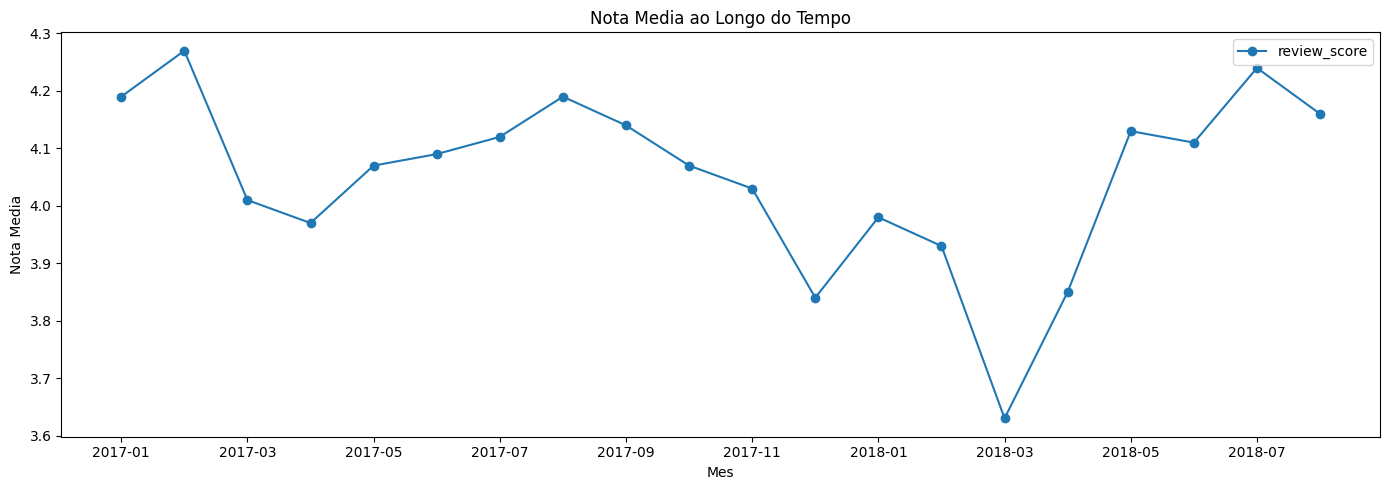

In [63]:
notas_tempo.index = notas_tempo.index.astype(str)

ax = notas_tempo.plot(kind='line', marker='o', figsize=(14, 5))
plt.title('Nota Media ao Longo do Tempo')
plt.xlabel('Mes')
plt.ylabel('Nota Media')
ax.set_xticks(range(0, len(notas_tempo), 2))
ax.set_xticklabels(notas_tempo.index[::2], rotation=0)
plt.tight_layout()
plt.show()

> **Insight:** a nota media oscila sem tendencia clara de melhora. Novembro/2017
> (Black Friday) e marco/2018 registraram as maiores quedas, sugerindo que
> picos de volume impactam negativamente a experiencia do cliente.

## 10. On Time vs Late Delivery Score

In [76]:
# 10. Qual a diferenca de nota entre entrega no prazo e atrasada?
notas = df_satisfaction.groupby('situacao')['review_score'].mean()

In [77]:
diferenca = notas['No Prazo'] - notas['Atrasado']
percentual = ((notas['No Prazo'] - notas['Atrasado']) / notas['Atrasado']) * 100

print(f"No Prazo  : {notas['No Prazo']:.2f}")
print(f"Atrasado  : {notas['Atrasado']:.2f}")
print(f"Diferenca : {diferenca:.2f} pontos")
print(f"Queda     : {percentual:.1f}%")

No Prazo  : 4.14
Atrasado  : 2.55
Diferenca : 1.59 pontos
Queda     : 62.3%


> **Insight principal:** entregas no prazo tem nota 62% maior que entregas
> atrasadas (4.14 vs 2.55). Pontualidade na entrega e o fator mais critico
> para a satisfacao do cliente na Olist.

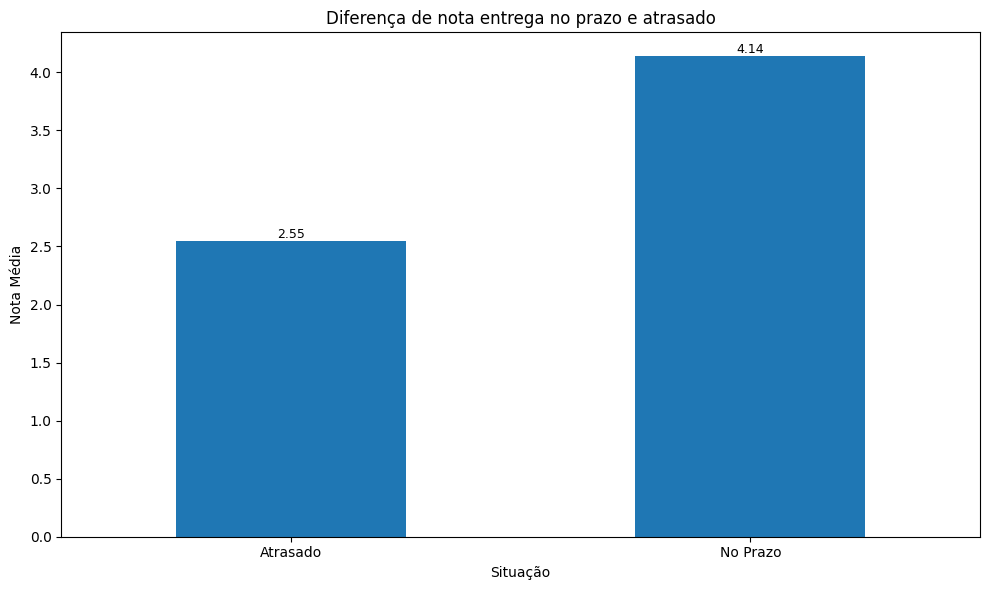

In [ ]:
ax = notas.plot(kind='bar', figsize=(10, 6))
plt.title('Diferença de nota entrega no prazo e atrasado')
plt.xlabel('Situação')
plt.ylabel('Nota Média')

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height(),                    
        f'{(bar.get_height()):,.2f}',      
        va='bottom',
        ha='center',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()